In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
index_names = ['unit_number', 'time_in_cycles']
setting_names = ['op_setting_1', 'op_setting_2', 'op_setting_3']
sensor_names = [f'sensor_{i}' for i in range(1, 22)]
col_names = index_names + setting_names + sensor_names

In [3]:
train_df = pd.read_csv(r"C:\Users\yuzhd\github\DataScience\scikit-learn\scikit-learn\data\CMaps\train_FD001.txt",sep='\s+',header=None,index_col=False,names=col_names)
test_df = pd.read_csv(r"C:\Users\yuzhd\github\DataScience\scikit-learn\scikit-learn\data\CMaps\test_FD001.txt",sep='\s+',header=None,index_col=False,names=col_names)
rul_df = pd.read_csv(r"C:\Users\yuzhd\github\DataScience\scikit-learn\scikit-learn\data\CMaps\RUL_FD001.txt",sep='\s+',header=None,index_col=False,names=['RUL'])

In [4]:
train_df.head(10)

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
5,1,6,-0.0043,-0.0001,100.0,518.67,642.10,1584.47,1398.37,14.62,...,521.68,2388.03,8132.85,8.4108,0.03,391,2388,100.0,38.98,23.3669
6,1,7,0.0010,0.0001,100.0,518.67,642.48,1592.32,1397.77,14.62,...,522.32,2388.03,8132.32,8.3974,0.03,392,2388,100.0,39.10,23.3774
7,1,8,-0.0034,0.0003,100.0,518.67,642.56,1582.96,1400.97,14.62,...,522.47,2388.03,8131.07,8.4076,0.03,391,2388,100.0,38.97,23.3106
8,1,9,0.0008,0.0001,100.0,518.67,642.12,1590.98,1394.80,14.62,...,521.79,2388.05,8125.69,8.3728,0.03,392,2388,100.0,39.05,23.4066
9,1,10,-0.0033,0.0001,100.0,518.67,641.71,1591.24,1400.46,14.62,...,521.79,2388.06,8129.38,8.4286,0.03,393,2388,100.0,38.95,23.4694


In [5]:
rename_dict = {
    "op_setting_1": "Alt[kft]", # Altitude
    "op_setting_2": "Mn[-]", # Mach number
    "op_setting_3": "TLA[deg]", # Thrust lever angle (detent?)
    "sensor_1": "T2[R]",  # Total temperature at fan inlet 
    "sensor_2": "T24[R]", # Total temperature at LPC outlet
    "sensor_3": "T30[R]", # Total temperature at HPC outlet
    "sensor_4": "T50[R]", # Total temperature at LPT outlet
    "sensor_5": "P2[psi]", # Pressure at fan inlet
    "sensor_6": "P15[psi]", # Total pressure in bypass-duct
    "sensor_7": "P30[psi]", # Total pressure at HPC outlet
    "sensor_8": "Nf[rpm]", # Physical fan speed
    "sensor_9": "Nc[rpm]", # Physical core speed
    "sensor_10": "epr[-]", # Engine pressure ratio (P50/P2)
    "sensor_11": "phi[pph/psi]", # Ratio of fuel flow to Ps30, (not pps/psi, but pph/psi)
    "sensor_12": "Ps30[psi]", # Static pressure at HPC outlet
    "sensor_13": "NRf[rpm]", # Corrected fan speed
    "sensor_14": "NRc[rpm]", # Corrected core speed
    "sensor_15": "BPR[-]", # Bypass Ratio
    "sensor_16": "farB[-]", # Burner fuel-air ratio
    "sensor_17": "htBleed[]",# Bleed Enthalpy
    "sensor_18": "Nf_dmd[rpm]", # Demanded fan speed
    "sensor_19": "PCNfR_dmd[Pct]", # Demanded corrected fan speed
    "sensor_20": "W31[lbm/s]", # HPT coolant bleed
    "sensor_21": "W32[lbm/s]", # LPT coolant bleed
}


train_df = train_df.rename(columns=rename_dict)
test_df  = test_df.rename(columns=rename_dict)

def clean_round(series, ndigits=1, eps=1e-6):
    """Round values and force -0.0 to 0.0"""
    rounded = series.round(ndigits)
    rounded[rounded.abs() < eps] = 0
    return rounded

train_df['condition'] = (
    clean_round(train_df["Alt[kft]"], 0).astype(str) + '_' +
    clean_round(train_df["Mn[-]"], 1).astype(str) + '_' +
    clean_round(train_df["TLA[deg]"], 0).astype(str)
)

train_df

,unit_number,time_in_cycles,Alt[kft],Mn[-],TLA[deg],T2[R],T24[R],T30[R],T50[R],P2[psi],...,NRf[rpm],NRc[rpm],BPR[-],farB[-],htBleed[],Nf_dmd[rpm],PCNfR_dmd[Pct],W31[lbm/s],W32[lbm/s],condition
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,0.0_0.0_100.0
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,0.0_0.0_100.0
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,0.0_0.0_100.0
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,0.0_0.0_100.0
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,0.0_0.0_100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735,0.0_0.0_100.0
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594,0.0_0.0_100.0
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333,0.0_0.0_100.0
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640,0.0_0.0_100.0


In [6]:
train_df.describe()

,unit_number,time_in_cycles,Alt[kft],Mn[-],TLA[deg],T2[R],T24[R],T30[R],T50[R],P2[psi],...,Ps30[psi],NRf[rpm],NRc[rpm],BPR[-],farB[-],htBleed[],Nf_dmd[rpm],PCNfR_dmd[Pct],W31[lbm/s],W32[lbm/s]
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,1.776400e-15,...,0.737553,0.071919,19.076176,0.037505,1.387812e-17,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


In [7]:
train_df.isnull().sum()

unit_number       0
time_in_cycles    0
Alt[kft]          0
Mn[-]             0
TLA[deg]          0
T2[R]             0
T24[R]            0
T30[R]            0
T50[R]            0
P2[psi]           0
P15[psi]          0
P30[psi]          0
Nf[rpm]           0
Nc[rpm]           0
epr[-]            0
phi[pph/psi]      0
Ps30[psi]         0
NRf[rpm]          0
NRc[rpm]          0
BPR[-]            0
farB[-]           0
htBleed[]         0
Nf_dmd[rpm]       0
PCNfR_dmd[Pct]    0
W31[lbm/s]        0
W32[lbm/s]        0
condition         0
dtype: int64

In [8]:
pd.set_option('display.max_rows', None)
summary_df = pd.DataFrame(train_df.dtypes, columns=['Data Type'])
summary_df = summary_df.reset_index()
summary_df = summary_df.rename(columns={'index': 'Column Name'})
summary_df['Non-Null Count'] = train_df.count().values
summary_df['Null Count'] = train_df.isnull().sum().values
summary_df['Null Ratio (%)'] = (train_df.isnull().sum().values / len(train_df)) * 100
summary_df

,Column Name,Data Type,Non-Null Count,Null Count,Null Ratio (%)
0,unit_number,int64,20631,0,0.0
1,time_in_cycles,int64,20631,0,0.0
2,Alt[kft],float64,20631,0,0.0
3,Mn[-],float64,20631,0,0.0
4,TLA[deg],float64,20631,0,0.0
5,T2[R],float64,20631,0,0.0
6,T24[R],float64,20631,0,0.0
7,T30[R],float64,20631,0,0.0
8,T50[R],float64,20631,0,0.0
9,P2[psi],float64,20631,0,0.0


### 컬럼 설명 (Data Dictionary)

| 컬럼명 | 설명 | 타입 |
|---|---|---|
| **unit_number** | 엔진 고유 식별자 (Unit Number) | int64 |
| **time_in_cycles** | 운전 사이클 (Time in Cycles) | int64 |
| **Alt[kft]** | 고도 (Altitude) | float64 |
| **Mn[-]** | 마하 수 (Mach Number) | float64 |
| **TLA[deg]** | 스로틀 레버 각도 (Thrust Lever Angle) | float64 |
| **T2[R]** | 팬 입구 전온도 (Total temperature at fan inlet) | float64 |
| **T24[R]** | LPC 출구 전온도 (Total temperature at LPC outlet) | float64 |
| **T30[R]** | HPC 출구 전온도 (Total temperature at HPC outlet) | float64 |
| **T50[R]** | LPT 출구 전온도 (Total temperature at LPT outlet) | float64 |
| **P2[psi]** | 팬 입구 압력 (Pressure at fan inlet) | float64 |
| **P15[psi]** | 바이패스 덕트 전압력 (Total pressure in bypass-duct) | float64 |
| **P30[psi]** | HPC 출구 전압력 (Total pressure at HPC outlet) | float64 |
| **Nf[rpm]** | 물리적 팬 속도 (Physical fan speed) | float64 |
| **Nc[rpm]** | 물리적 코어 속도 (Physical core speed) | float64 |
| **epr[-]** | 엔진 압력비 (Engine pressure ratio) | float64 |
| **phi[pph/psi]** | 연료 유량 대 Ps30 비율 (Ratio of fuel flow to Ps30) | float64 |
| **Ps30[psi]** | HPC 출구 정압 (Static pressure at HPC outlet) | float64 |
| **NRf[rpm]** | 보정된 팬 속도 (Corrected fan speed) | float64 |
| **NRc[rpm]** | 보정된 코어 속도 (Corrected core speed) | float64 |
| **BPR[-]** | 바이패스 비 (Bypass Ratio) | float64 |
| **farB[-]** | 연소기 연료-공기 비 (Burner fuel-air ratio) | float64 |
| **htBleed[]** | 블리드 엔탈피 (Bleed Enthalpy) | int64 |
| **Nf_dmd[rpm]** | 요구 팬 속도 (Demanded fan speed) | int64 |
| **PCNfR_dmd[Pct]** | 요구 보정 팬 속도 (Demanded corrected fan speed) | float64 |
| **W31[lbm/s]** | HPT 냉각 블리드 (HPT coolant bleed) | float64 |
| **W32[lbm/s]** | LPT 냉각 블리드 (LPT coolant bleed) | float64 |
| **condition** | 운전 조건 문자열 (Operational Condition String) | object |

* 참고
| **RUL** | 엔진의 남은 수명 (Remaining Useful Life) | int64 |

In [9]:
train_df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   unit_number     20631 non-null  int64  
 1   time_in_cycles  20631 non-null  int64  
 2   Alt[kft]        20631 non-null  float64
 3   Mn[-]           20631 non-null  float64
 4   TLA[deg]        20631 non-null  float64
 5   T2[R]           20631 non-null  float64
 6   T24[R]          20631 non-null  float64
 7   T30[R]          20631 non-null  float64
 8   T50[R]          20631 non-null  float64
 9   P2[psi]         20631 non-null  float64
 10  P15[psi]        20631 non-null  float64
 11  P30[psi]        20631 non-null  float64
 12  Nf[rpm]         20631 non-null  float64
 13  Nc[rpm]         20631 non-null  float64
 14  epr[-]          20631 non-null  float64
 15  phi[pph/psi]    20631 non-null  float64
 16  Ps30[psi]       20631 non-null  float64
 17  NRf[rpm]        20631 non-null 

In [10]:
train_df.columns

Index(['unit_number', 'time_in_cycles', 'Alt[kft]', 'Mn[-]', 'TLA[deg]',
       'T2[R]', 'T24[R]', 'T30[R]', 'T50[R]', 'P2[psi]', 'P15[psi]',
       'P30[psi]', 'Nf[rpm]', 'Nc[rpm]', 'epr[-]', 'phi[pph/psi]', 'Ps30[psi]',
       'NRf[rpm]', 'NRc[rpm]', 'BPR[-]', 'farB[-]', 'htBleed[]', 'Nf_dmd[rpm]',
       'PCNfR_dmd[Pct]', 'W31[lbm/s]', 'W32[lbm/s]', 'condition'],
      dtype='object')

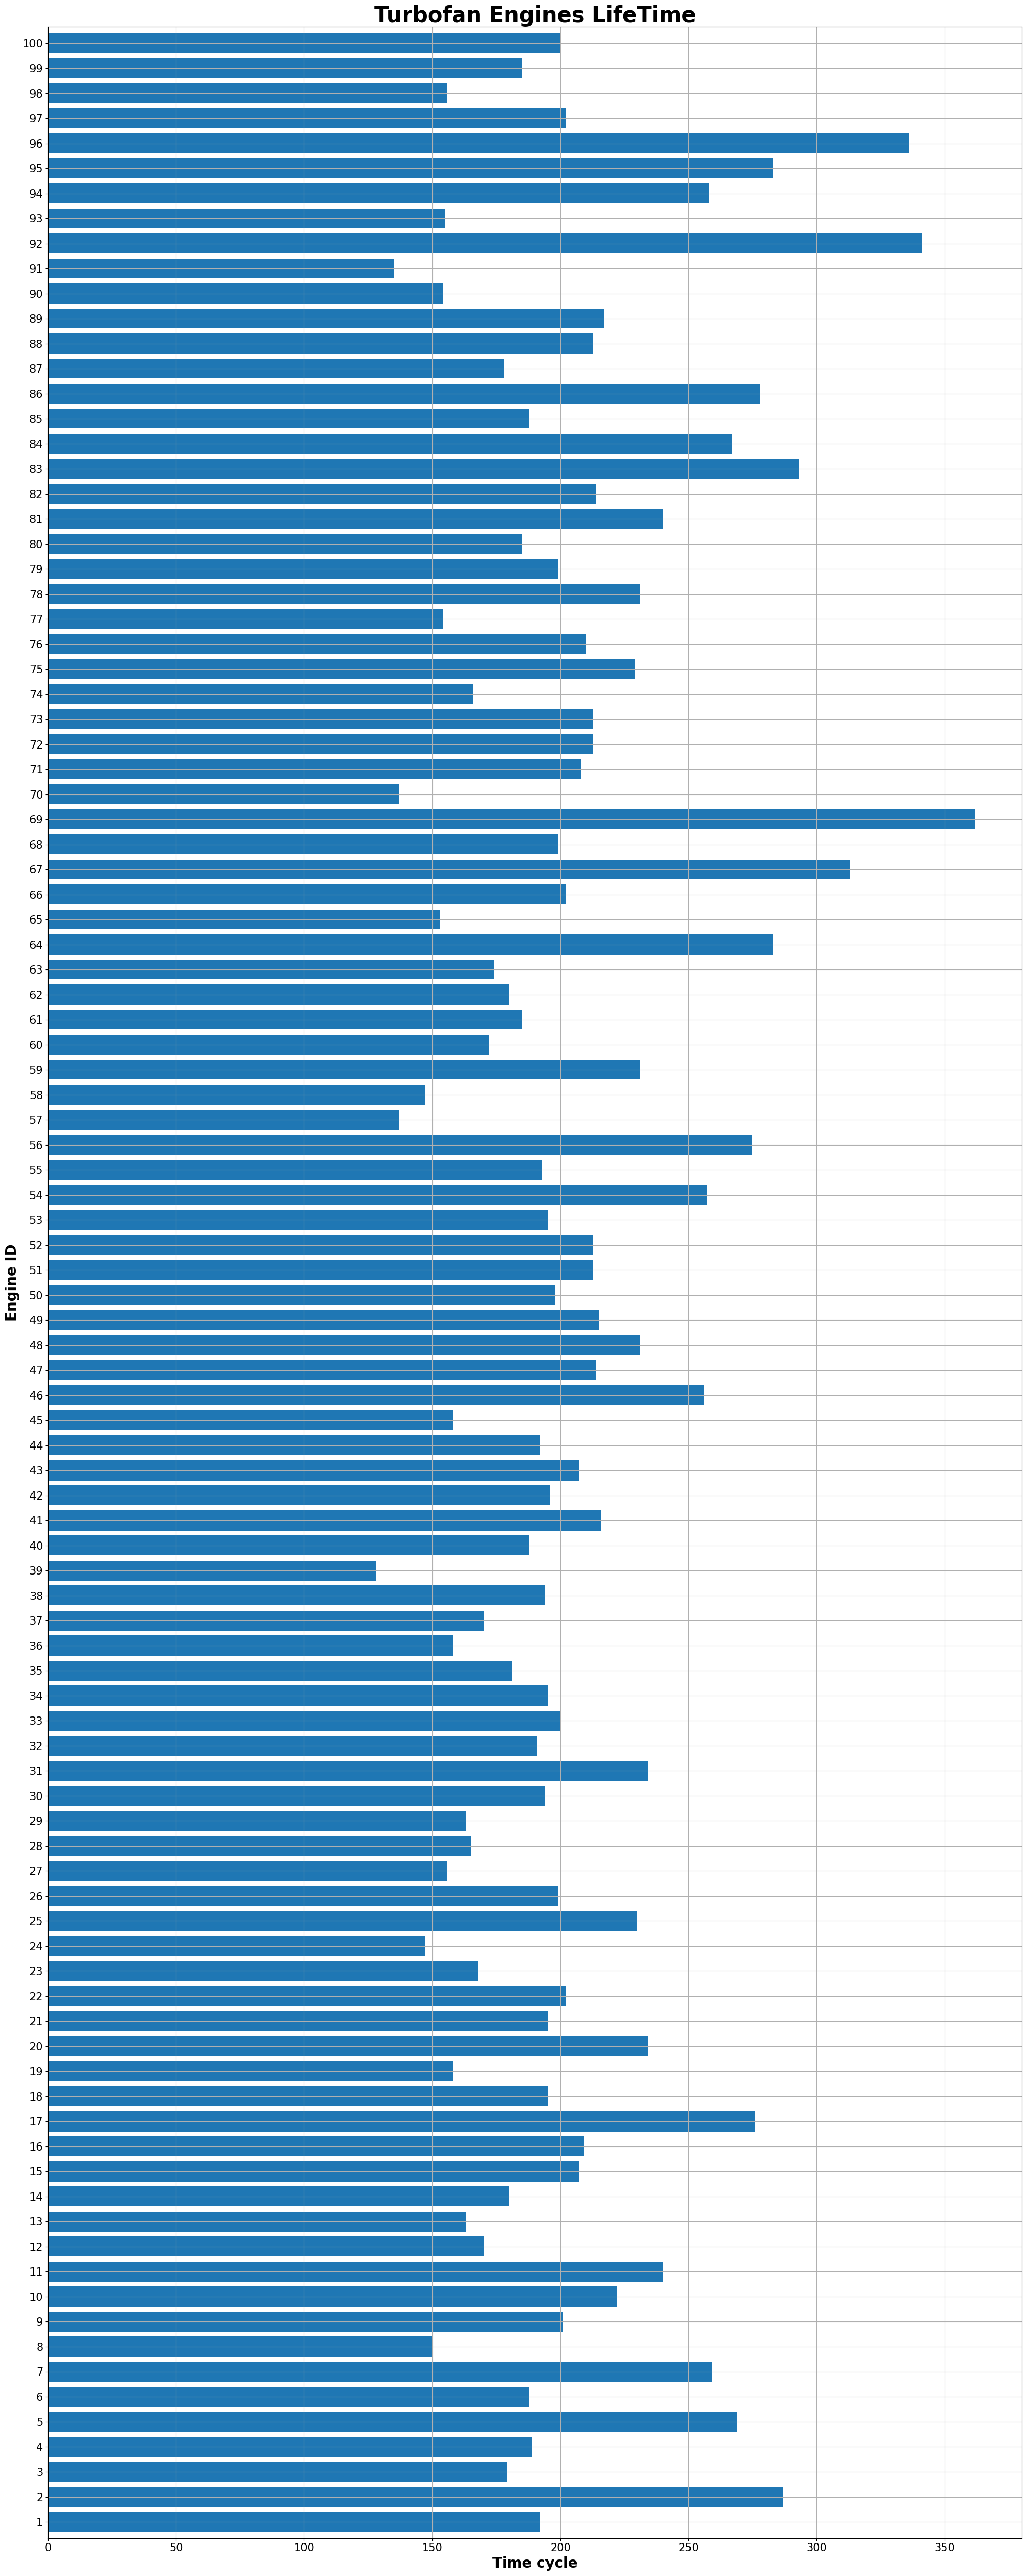

In [ ]:
# 엔진별 수명 시각화

max_time_cycles=train_df[['unit_number','time_in_cycles']].groupby('unit_number').max()
plt.figure(figsize=(20,50))
ax=max_time_cycles['time_in_cycles'].plot(kind='barh',width=0.8, stacked=True,align='center')
plt.title('Turbofan Engines LifeTime',fontweight='bold',size=30)
plt.xlabel('Time cycle',fontweight='bold',size=20)
plt.xticks(size=15)
plt.ylabel('Engine ID',fontweight='bold',size=20)
plt.yticks(size=15)
plt.grid(True)
plt.tight_layout()
plt.show()

Text(0.5, 9.444444444444459, 'max time in cycles')

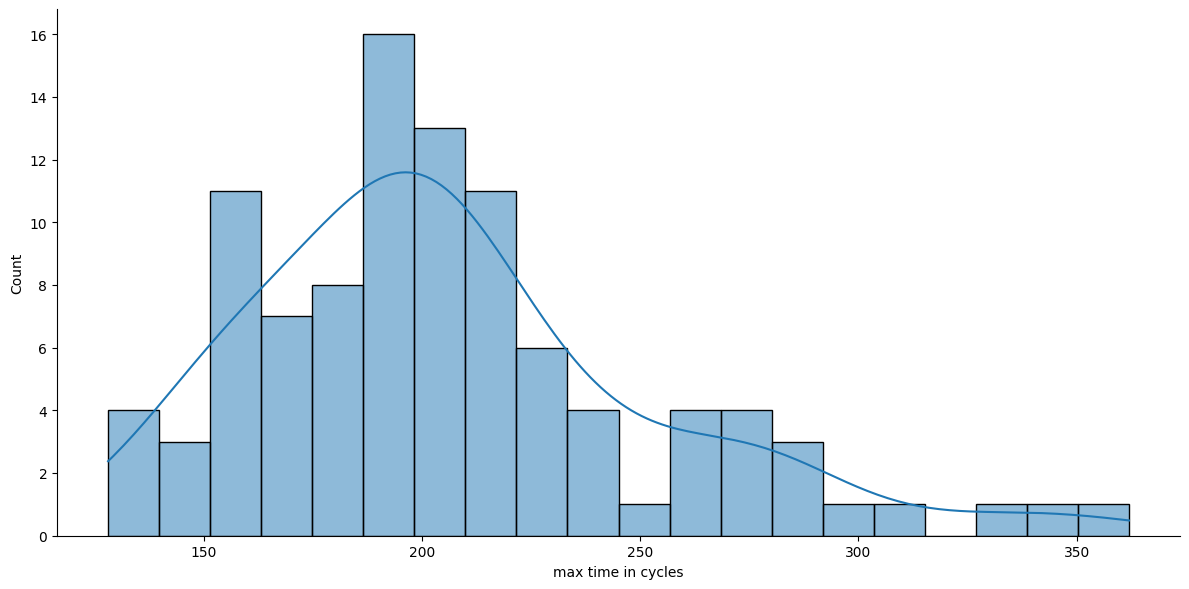

In [17]:
#Distribution of maximum time cycles
sns.displot(max_time_cycles['time_in_cycles'],kde=True,bins=20,height=6,aspect=2)
plt.xlabel('max time in cycles')

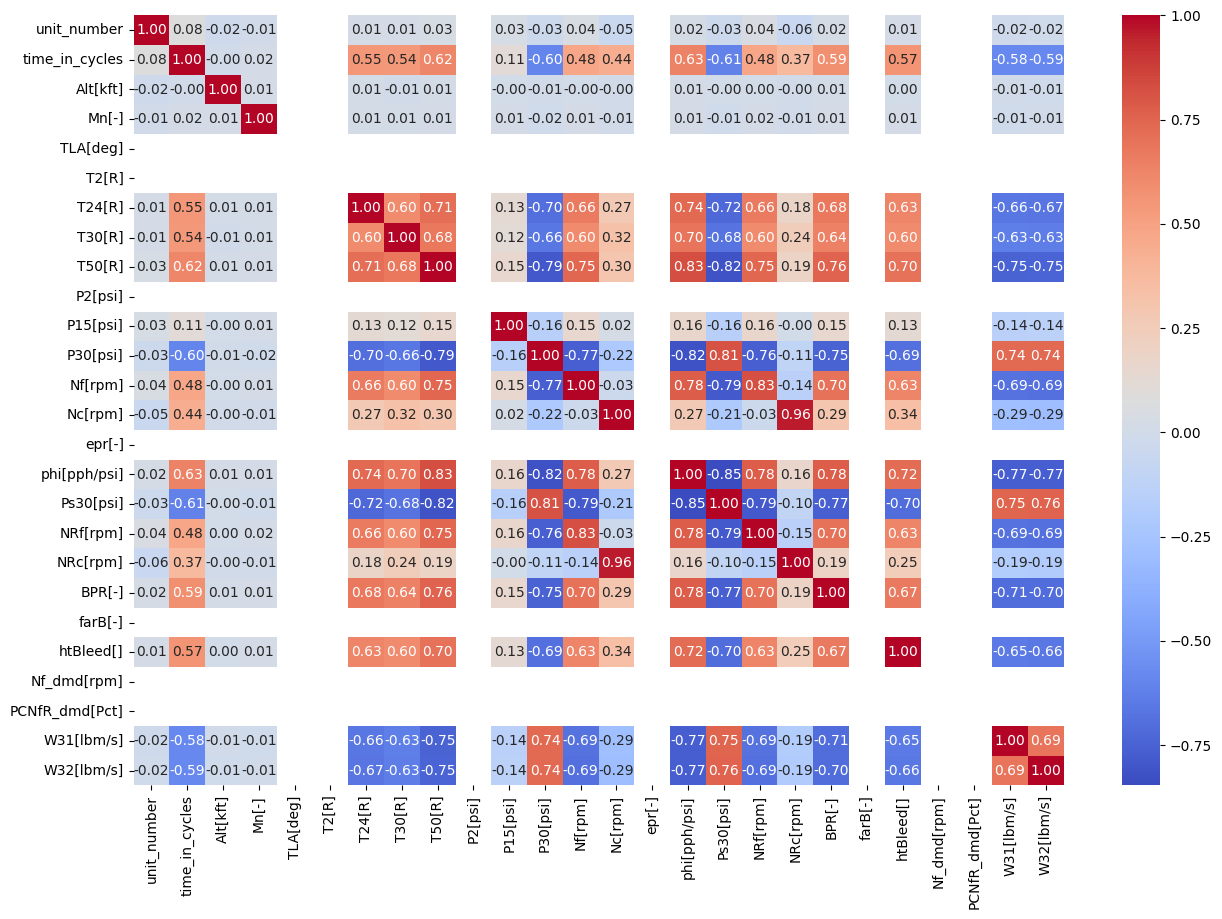

In [32]:
plt.figure(figsize=(15, 10))
sns.heatmap(train_df.corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

In [36]:
# 1. 엔진(unit_number)별로 가장 큰 사이클 번호를 찾습니다.
max_cycle = train_df.groupby('unit_number')['time_in_cycles'].max().reset_index()
max_cycle.columns = ['unit_number', 'max_cycle']

# 2. 원본 데이터에 최대 수명 정보를 합칩니다.
train_df = train_df.merge(max_cycle, on='unit_number', how='left')

# 3. RUL = 최대 수명 - 현재 사이클
train_df['RUL'] = train_df['max_cycle'] - train_df['time_in_cycles']

# 사용이 끝난 max_cycle 컬럼은 삭제합니다.
train_df.drop('max_cycle', axis=1, inplace=True)

print("RUL 컬럼 생성 완료!")
train_df[['unit_number', 'time_in_cycles', 'RUL']].head()

RUL 컬럼 생성 완료!


,unit_number,time_in_cycles,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187


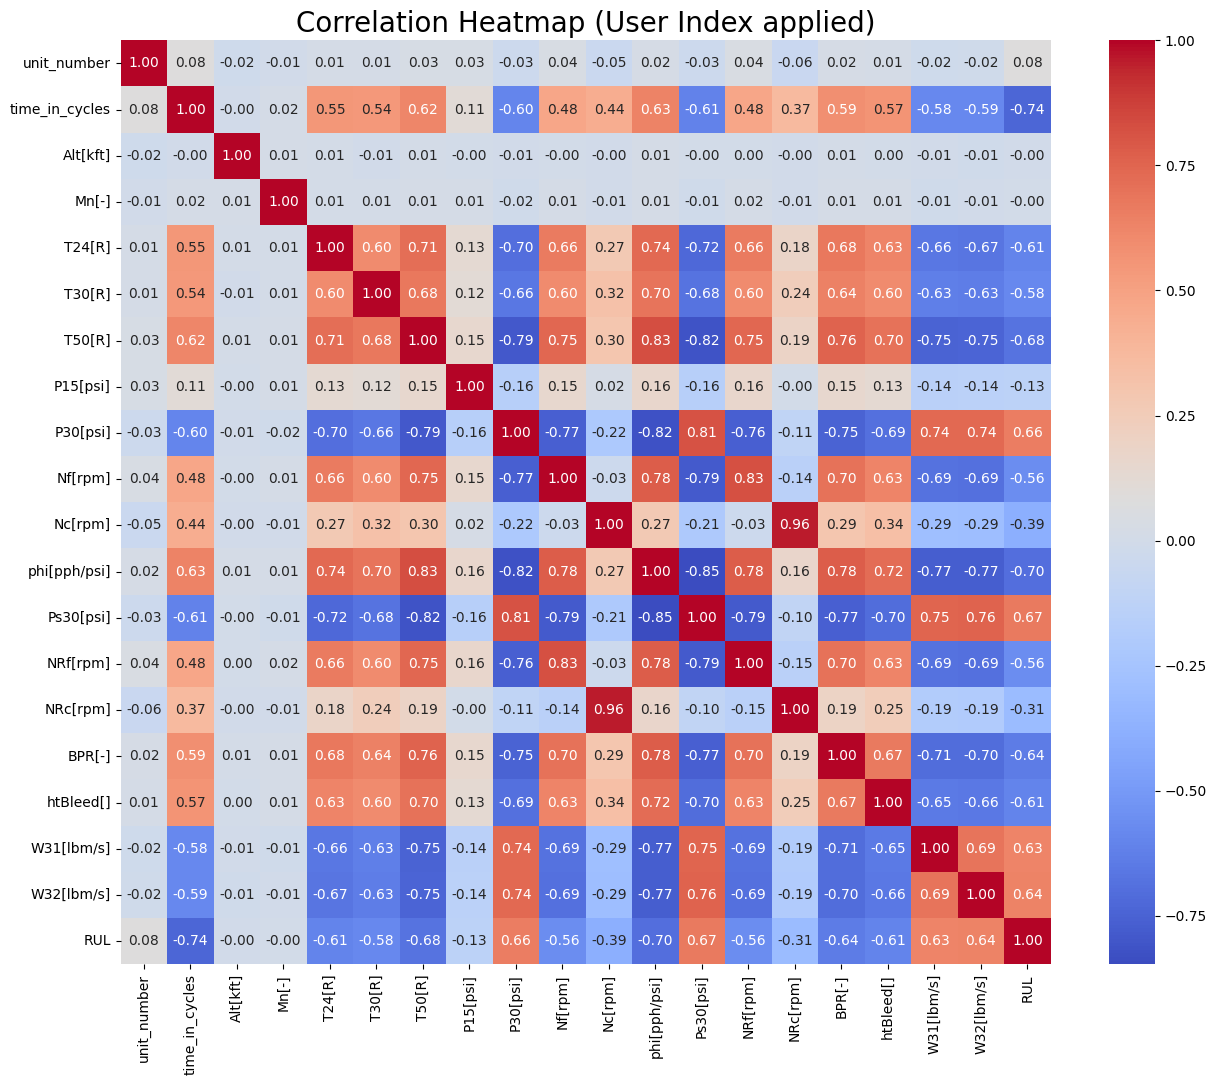

--- RUL과 상관관계가 높은 순서 ---
RUL               1.000000
Ps30[psi]         0.671983
P30[psi]          0.657223
W32[lbm/s]        0.635662
W31[lbm/s]        0.629428
unit_number       0.078753
Mn[-]            -0.001948
Alt[kft]         -0.003198
P15[psi]         -0.128348
NRc[rpm]         -0.306769
Nc[rpm]          -0.390102
NRf[rpm]         -0.562569
Nf[rpm]          -0.563968
T30[R]           -0.584520
htBleed[]        -0.606154
T24[R]           -0.606484
BPR[-]           -0.642667
T50[R]           -0.678948
phi[pph/psi]     -0.696228
time_in_cycles   -0.736241
Name: RUL, dtype: float64


In [43]:
# 4. 상관관계 계산 (숫자 데이터만!)
plt.figure(figsize=(15, 12))

# RUL과 센서들 간의 상관관계만 뽑아서 보기 좋게 정렬합니다.
correlations = train_df.corr(numeric_only=True)['RUL'].sort_values(ascending=False)

# 히트맵 그리기
sns.heatmap(train_df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap (User Index applied)', fontsize=20)
plt.show()

print("--- RUL과 상관관계가 높은 순서 ---")
print(correlations)

In [51]:
# 1. 🔍 값이 변하지 않는(분산이 0인) 무의미한 컬럼 자동 추출
constant_columns = [col for col in train_df.columns if train_df[col].nunique() <= 1]

# 2. 📝 자동으로 찾은 고정값 컬럼에 'sensor_6'와 'op_setting_3'를 추가
cols_to_drop = list(set(constant_columns + ['sensor_6', 'op_setting_3']))

# 3. ✂️ 데이터프레임에서 불필요한 컬럼 삭제 실행
train_df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print(f"❌ 삭제된 컬럼 목록: {cols_to_drop}")
print(f"✅ 남은 컬럼 개수: {len(train_df.columns)}개")
print(f"📊 현재 컬럼 목록: {train_df.columns.tolist()}")

❌ 삭제된 컬럼 목록: ['sensor_6', 'op_setting_3']
✅ 남은 컬럼 개수: 20개
📊 현재 컬럼 목록: ['unit_number', 'time_in_cycles', 'Alt[kft]', 'Mn[-]', 'T24[R]', 'T30[R]', 'T50[R]', 'P15[psi]', 'P30[psi]', 'Nf[rpm]', 'Nc[rpm]', 'phi[pph/psi]', 'Ps30[psi]', 'NRf[rpm]', 'NRc[rpm]', 'BPR[-]', 'htBleed[]', 'W31[lbm/s]', 'W32[lbm/s]', 'RUL']


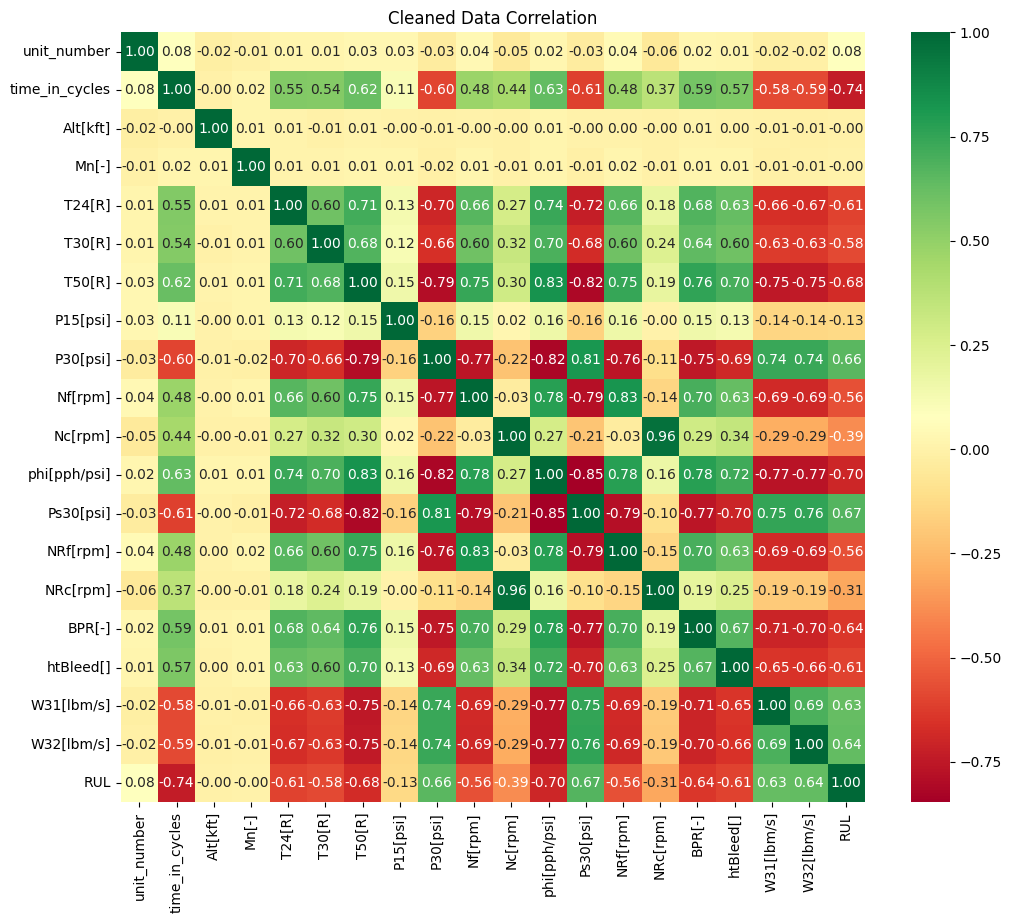

In [44]:
# 3. 깨끗해진 데이터로 상관관계 히트맵 다시 그리기
plt.figure(figsize=(12, 10))
sns.heatmap(train_df.corr(numeric_only=True), annot=True, cmap='RdYlGn', fmt=".2f")
plt.title("Cleaned Data Correlation")
plt.show()